In [2]:
import pandas as pd
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

#Google Drive ID for public sharing of the dataset
file_id = "1JwxB18_ed4NyDeDX2e5ytsO7YIRS80QN"
file = drive.CreateFile({'id': file_id})
file.GetContentFile('drug200.csv')

#Reading the csv and loading it into a pandas dataframe.
df = pd.read_csv('drug200.csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


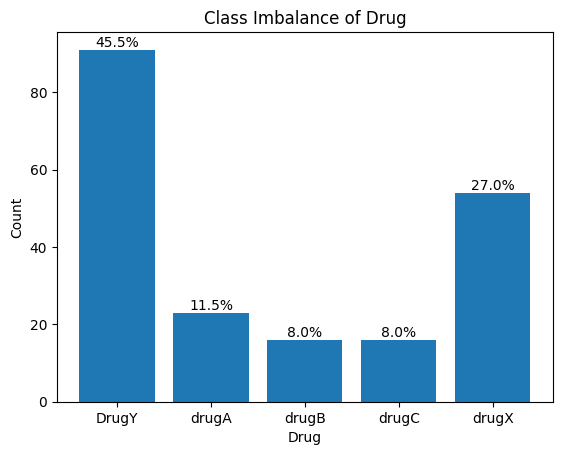

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

drugs = df['Drug'].to_numpy()
unique, counts = np.unique(drugs, return_counts=True)

# Bar chart
plt.bar(unique, counts)

# Percentage of each drug
total = len(drugs)
for i in range(len(unique)):
    percentage = (counts[i] / total) * 100
    plt.text(
        i,
        counts[i],
        f"{percentage:.1f}%",
        ha='center',
        va='bottom'
    )
plt.xlabel("Drug")
plt.ylabel("Count")
plt.title("Class Imbalance of Drug")
plt.show()

In [ ]:
import numpy as np
import plotly.express as px

# Extract data using numpy
age = df['Age'].to_numpy()
na_to_k = df['Na_to_K'].to_numpy()
bp = df['BP'].to_numpy()

# Create a dictionary to hold the data for plotly
plot_data = {
    'Age': age,
    'Na_to_K': na_to_k,
    'BP': bp
}

# Create the scatter plot using plotly.express
fig = px.scatter(plot_data, x='Age', y='Na_to_K', color='BP',
                 title='Age vs Na_to_K by Blood Pressure',
                 labels={'Age': 'Age', 'Na_to_K': 'Na_to_K'})

fig.update_layout(width=800, height=500) # Adjust figure size
fig.show()

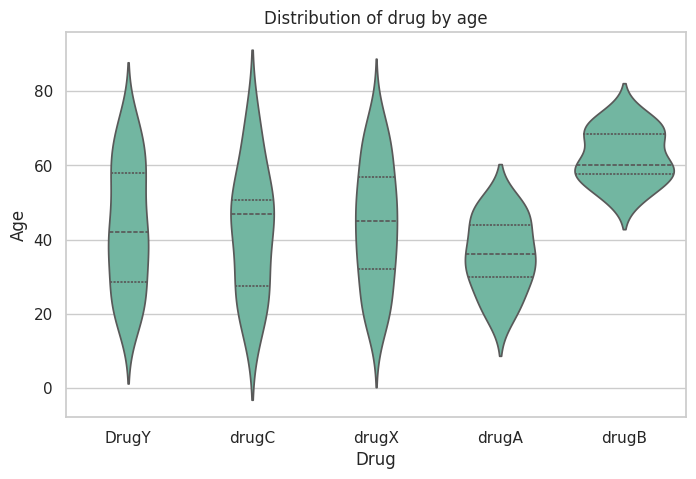

In [ ]:
import seaborn as sns
sns.set(style="whitegrid", palette="Set2")

plt.figure(figsize=(8,5))
sns.violinplot(data=df, x="Drug", y="Age", inner="quartile")

plt.title("Distribution of drug by age")

plt.show()

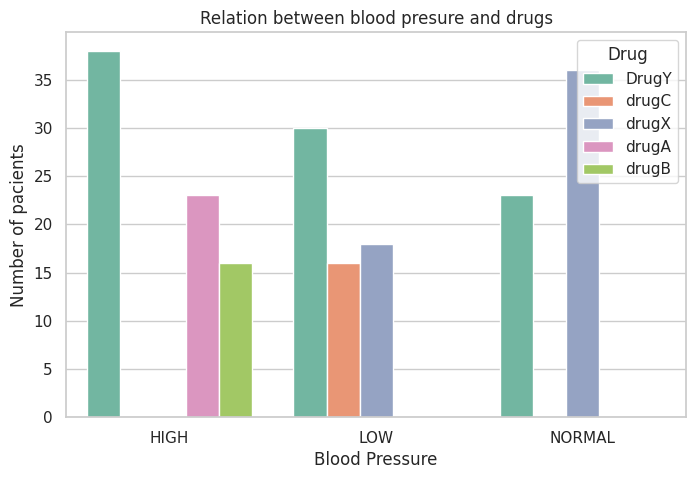

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="BP", hue="Drug")

plt.title("Relation between blood presure and drugs")
plt.xlabel("Blood Pressure")
plt.ylabel("Number of pacients")

plt.show()

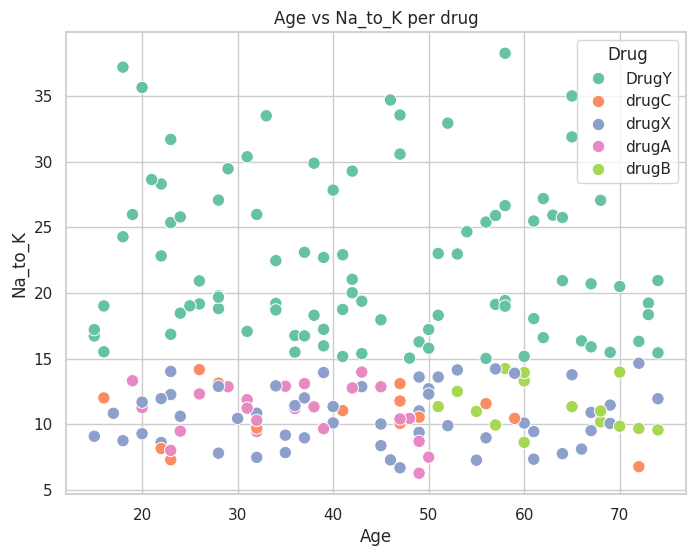

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Age", y="Na_to_K", hue="Drug", s=80)

plt.title("Age vs Na_to_K per drug")

plt.show()

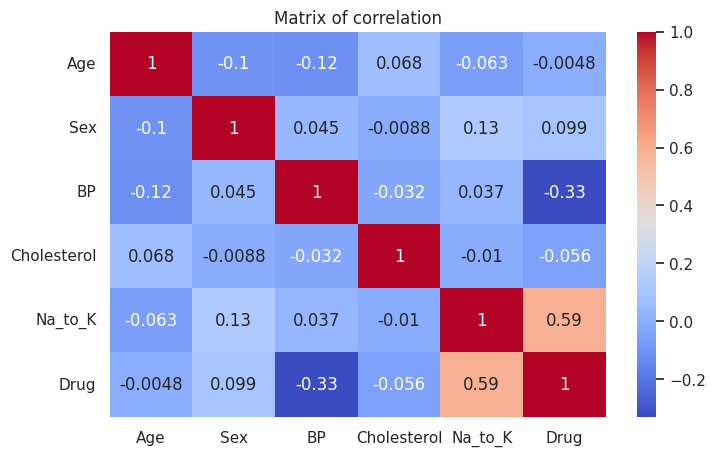

In [ ]:
df_encoded = df.copy()

df_encoded["Sex"] = df_encoded["Sex"].map({"M":0,"F":1})
df_encoded["BP"] = df_encoded["BP"].map({"LOW":0,"NORMAL":1,"HIGH":2})
df_encoded["Cholesterol"] = df_encoded["Cholesterol"].map({"NORMAL":0,"HIGH":1})

df_encoded["Drug"] = df_encoded["Drug"].map({
    "drugA":0,
    "drugB":1,
    "drugC":2,
    "drugX":3,
    "DrugY":4
})

plt.figure(figsize=(8,5))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")

plt.title("Matrix of correlation")
plt.show()

# Data Processing

In [7]:
# Import libraries
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -------------------------
# 1. Analyze missing values
# -------------------------

print("Missing values per column:")
print(df.isnull().sum())

# If there were missing values we could do:
# df.fillna(method='ffill')  OR  df.fillna(df.mean())

# -------------------------
# 2. Separate features and target
# -------------------------

X = df.drop("Drug", axis=1)
y = df["Drug"]

# -------------------------
# 3. Define categorical and numerical columns
# -------------------------

categorical_features = ["Sex", "BP", "Cholesterol"]
numerical_features = ["Age", "Na_to_K"]

# -------------------------
# 4. Create preprocessing steps
# -------------------------

# One-Hot Encoding for categorical variables
categorical_transformer = OneHotEncoder()

# Standardization for numerical variables
numerical_transformer = StandardScaler()

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# -------------------------
# 5. Apply preprocessing
# -------------------------

X_processed = preprocessor.fit_transform(X)

print("Processed dataset shape:")
print(X_processed.shape)

Missing values per column:
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64
Processed dataset shape:
(200, 9)


# Imbalance Analysis and Mitigation

# Model Comparison and Hyperparameter Tuning

# Results Discussion

# Lessons Learned